## C1 - WEEK 2

- Adrià Cantarero Carreras  (1809773@uab.cat)
- Ivan Martin Campoy (1673246@uab.cat)
- Irene Pumares Benaiges (1810704@uab.cat)
- Lavish Ramchandani (1691238@uab.cat)

In [1]:
#needed libraries

import os
import re
import cv2
import pickle
import numpy as np
from functools import partial
from tqdm.auto import tqdm
import time
import matplotlib.pyplot as plt




## TASK 1: Implement 3D / 2D and block and hierarchical histograms

In [2]:
#database and qsd1 and qsd2 paths

bbdd_path = "./BBDD"
qsd2_path = "./qsd2_w1"
qsd1_path = "./qsd1_w1"

COLOR_SPACES = {
    "GRAY": cv2.COLOR_BGR2GRAY,
    "RGB":  cv2.COLOR_BGR2RGB,
    "HSV":  cv2.COLOR_BGR2HSV,
    "LAB":  cv2.COLOR_BGR2LAB,
    "YCRCB": cv2.COLOR_BGR2YCrCb,
}
#----------------------------------------------------------------------------------

CHANNEL_RANGES = {
    "GRAY":  [(0, 256)],
    "RGB":   [(0, 256)] * 3,
    "HSV":   [(0, 180), (0, 256), (0, 256)],
    "LAB":   [(0, 256)] * 3,
    "YCRCB": [(0, 256)] * 3,
}

def read_image(img_path):
    image = cv2.imread(img_path)
    if image is None:
        raise IOError(f"Could not read {img_path}")   #skipping it would shift every index after it and break the ground truth
    return image

bbdd_descriptors = []
qsd2_descriptors = []

#----------------------------------------------------------------------------------
#sort files
def return_number(string):
    return [int(text) if text.isdigit() else text.lower() for text in re.split(r'(\d+)', string)]

#sort bbdd files
bbdd_files = [f for f in os.listdir(bbdd_path) if f.lower().endswith(".jpg")]
bbdd_files.sort(key=return_number)

#sort qsd2 files
qsd2_files = [f for f in os.listdir(qsd2_path) if f.lower().endswith(".jpg")]
qsd2_files.sort(key=return_number)

qsd1_files = [f for f in os.listdir(qsd1_path) if f.lower().endswith(".jpg")]
qsd1_files.sort(key=return_number)

#id of an image = number in its file name (bbdd_00007.jpg -> 7)
def image_id(file_name):
    return int(re.findall(r'\d+', file_name)[-1])

bbdd_ids = np.array([image_id(f) for f in bbdd_files])
qsd2_ids = np.array([image_id(f) for f in qsd2_files])
qsd1_ids = np.array([image_id(f) for f in qsd1_files])
#----------------------------------------------------------------------------------

#load images iteratively bbdd set
bbdd_imgs = []
for file_name in bbdd_files:
    img_path = os.path.join(bbdd_path, file_name)
    image = read_image(img_path)
    bbdd_imgs.append(image)

qsd1_imgs = []
for file_name in qsd1_files:
    img_path = os.path.join(qsd1_path, file_name)
    image = read_image(img_path)
    qsd1_imgs.append(image)

##load images iteratively qsd2 set
qsd2_imgs = []
for file_name in qsd2_files:
    img_path = os.path.join(qsd2_path, file_name)
    image = read_image(img_path)
    qsd2_imgs.append(image)

In [3]:
def compute_nd_histogram(image,color_space = 'HSV', channels = (1,2), bins= 16, mask = None):
    if mask is not None:
        mask = (mask > 0).astype(np.uint8) * 255 #convert boolean mask to 0-255 just in case

    ranges = [] #ranges for the color space channels
    if color_space in COLOR_SPACES:
        converted_image = cv2.cvtColor(image, COLOR_SPACES[color_space])
        if len(converted_image.shape) == 2:
            raise ValueError("Descriptor needs 2 channels at least")

        for c in channels:
            ranges.extend(CHANNEL_RANGES[color_space][c])

    else:
        raise ValueError("Unknown color space: %s" % color_space)

    if isinstance(bins, int):
        hist_size = [bins for i in channels] #ex 16 -> (16,16)
    else:
        assert len(bins) == len(channels), "Number of bins must match number of channels"
        hist_size = bins
  
    hist = cv2.calcHist([converted_image], list(channels), mask, hist_size, ranges)
    hist = hist.flatten()

    #normalize only once
    total = np.sum(hist)
    if total > 0:
        hist = hist / total
    return hist


image = cv2.imread("./BBDD/bbdd_00000.jpg")
d = compute_nd_histogram(image)


In [4]:
def compute_block_histogram(image, grid=(4, 4), color_space='HSV', channels=(1, 2), bins=16, mask=None):
    # 1. block boundaries
    rows, cols = grid
    height, width = image.shape[:2]
    y_cuts  = np.linspace(0, height, rows + 1, dtype=int)
    x_cuts  = np.linspace(0, width, cols + 1, dtype=int)
    block_histograms = []

    # 2. loop over blocks: slice image (and mask), call compute_nd_histogram
    for r in range(rows):
        for c in range(cols):
            y_start, y_end = y_cuts[r], y_cuts[r+1]
            x_start, x_end = x_cuts[c], x_cuts[c+1]
            block_img = image[y_start:y_end, x_start:x_end]
            block_mask = None
            if mask is not None:
                block_mask = mask[y_start:y_end, x_start:x_end]
        
            hist = compute_nd_histogram(block_img, color_space, channels, bins, block_mask)
            block_histograms.append(hist)

    # 3. concatenate (and decide the normalization)
    descriptor = np.concatenate(block_histograms)
    total = np.sum(descriptor)
    if total > 0:
        descriptor = descriptor / total
    return descriptor

image = cv2.imread("./BBDD/bbdd_00000.jpg")
d = compute_block_histogram(image)


In [5]:
def compute_pyramid_histogram(image, levels=((1, 1), (2, 2), (4, 4)), weights=None,
                              color_space='HSV', channels=(0, 1), bins=16, mask=None):
    if weights is None:
        weights = np.ones(len(levels), dtype=np.float32) #default to equal weights if none passed
    else:
        weights = np.asarray(weights, dtype=np.float32) #convert weights to numpy array just in case

    assert len(weights) == len(levels), "len(weights) must match len(levels)" #make sure weight count matches level count

    if color_space in COLOR_SPACES:
        converted_image = cv2.cvtColor(image, COLOR_SPACES[color_space]) #convert color space once here to save time
    else:
        raise ValueError(f"Unknown color space: {color_space}") #throw error if color space isnt valid

    n_channels = len(channels) #count active channels
    hist_size = (bins,) * n_channels if isinstance(bins, int) else tuple(bins) #build tuple for bin counts
    bins_per_block = np.prod(hist_size) #total bins in a single block
    
    total_blocks = sum(r * c for r, c in levels) #sum all blocks across every level
    descriptor = np.empty(total_blocks * bins_per_block, dtype=np.float32) #preallocate full output vector upfront

    ranges = []
    for c in channels:
        ranges.extend(CHANNEL_RANGES[color_space][c]) #grab min max range for each channel

    if mask is not None:
        mask = (mask > 0).astype(np.uint8) * 255 #make sure mask is uint8 for opencv

    height, width = converted_image.shape[:2] #grab image dimensions
    offset = 0 #pointer to fill the descriptor array

    for (rows, cols), w in zip(levels, weights):
        y_cuts = np.linspace(0, height, rows + 1, dtype=int) #calculate vertical cuts for grid
        x_cuts = np.linspace(0, width, cols + 1, dtype=int) #calculate horizontal cuts for grid

        for r in range(rows):
            for c in range(cols):
                y0, y1 = y_cuts[r], y_cuts[r+1] #crop boundaries for y
                x0, x1 = x_cuts[c], x_cuts[c+1] #crop boundaries for x
                
                block_img = converted_image[y0:y1, x0:x1] #slice current block from image
                block_mask = mask[y0:y1, x0:x1] if mask is not None else None #slice matching mask area if present

                hist = cv2.calcHist([block_img], list(channels), block_mask, hist_size, ranges).ravel() #calc block hist
                
                block_total = hist.sum() #sum up all bins in block
                if block_total > 0:
                    hist /= block_total #normalize block so it sums to 1

                next_offset = offset + bins_per_block #compute end slice position
                descriptor[offset:next_offset] = hist * w #store weighted block directly in place
                offset = next_offset #slide pointer forward for next block

    total = descriptor.sum() #sum entire combined descriptor
    if total > 0:
        descriptor /= total #final l1 normalization on whole vector

    return descriptor

## Task2: Test query system using query set QSD1-W2 development, evaluate retrieval results (use your best performing descriptor).
Compare results against the best descriptor/distance in W1 (the dev set is the same)

In [6]:
eps = 1e-10  # small value to avoid division by zero


def euclidean_distance(x, y):
    return np.sqrt(np.sum((x - y) ** 2, axis=-1))

def L1_distance(x, y):
    return np.sum(np.abs(x - y), axis=-1)

def chi_squared_distance(x, y):
    return 0.5 * np.sum(((x - y) ** 2) / (x + y + eps), axis=-1)

def jensen_shannon_distance(x, y):
    m = 0.5 * (x + y)
    kl_x = np.sum(x * np.log((x + eps) / (m + eps)), axis=-1)
    kl_y = np.sum(y * np.log((y + eps) / (m + eps)), axis=-1)
    return np.sqrt(np.clip(0.5 * (kl_x + kl_y), 0, None))

#all the measures below are written as distances (smaller = more similar) because the retrieval step will rank every measure 
#with the same rule (sort ascending and take the first k)

def histogram_intersection_distance(x, y):
    return 1.0 - np.sum(np.minimum(x, y), axis=-1)

def hellinger_distance(x, y):
    return (1.0 / np.sqrt(2.0)) * np.sqrt(np.sum((np.sqrt(np.clip(x, 0, None)) - np.sqrt(np.clip(y, 0, None))) ** 2, axis=-1))

def cosine_distance(x, y):
    return 1.0 - np.sum(x * y, axis=-1) / (np.linalg.norm(x, axis=-1) * np.linalg.norm(y, axis=-1) + eps)

def correlation_distance(x, y):
    xc = x - np.mean(x, axis=-1, keepdims=True)
    yc = y - np.mean(y, axis=-1, keepdims=True)
    return 1.0 - np.sum(xc * yc, axis=-1) / (np.linalg.norm(xc, axis=-1) * np.linalg.norm(yc, axis=-1) + eps)

MEASURES = {
    "euclidean":      euclidean_distance,
    "L1":             L1_distance,
    "chi2":           chi_squared_distance,
    "intersection":   histogram_intersection_distance,
    "hellinger":      hellinger_distance,
    "cosine":         cosine_distance,
    "correlation":    correlation_distance,
    "jensen_shannon": jensen_shannon_distance,
}

# import ml_metrics as metrics #Couldn't install it so I copied the code from the git

import numpy as np

#code from https://github.com/benhamner/Metrics/blob/master/Python/ml_metrics/custom/kdd_average_precision.py
def kdd_apk(actual, predicted, k=10):
    """
    Computes the average precision at k for Track 1 of the 2012 KDD Cup.

    This modified version uses the number of actual clicks as the denominator,
    regardless of k.

    This function computes the average prescision at k between two lists of
    items.

    Parameters
    ----------
    actual : list
             A list of elements that are to be predicted (order doesn't matter)
    predicted : list
                A list of predicted elements (order does matter)
    k : int, optional
        The maximum number of predicted elements

    Returns
    -------
    score : double
            The average precision at k over the input lists

    """
    if len(predicted)>k:
        predicted = predicted[:k]

    score = 0.0
    num_hits = 0.0

    for i,p in enumerate(predicted):
        if p in actual and p not in predicted[:i]: #p not in predicted[:i] is to avoid no extra marks for repeating
            num_hits += 1.0
            score += num_hits / (i+1.0)

    if not actual:
        return 0.0

    return score / len(actual)

def kdd_mapk(actual, predicted, k=10):
    """
    Computes the mean average precision at k for Track 1 of the 2012 KDD Cup.

    This modified version uses the number of actual clicks as the denominator,
    regardless of k.

    This function computes the mean average prescision at k between two lists
    of lists of items.

    Parameters
    ----------
    actual : list
             A list of lists of elements that are to be predicted 
             (order doesn't matter in the lists)
    predicted : list
                A list of lists of predicted elements
                (order matters in the lists)
    k : int, optional
        The maximum number of predicted elements

    Returns
    -------
    score : double
            The mean average precision at k over the input lists

    """
    return np.mean([kdd_apk(a,p,k) for a,p in zip(actual, predicted)])


#apk is like the average precision of hits at k items
#but mapk looks in the entire dataset

import pandas as pd
from IPython.display import display

gt_path = os.path.join(qsd1_path, "gt_corresps.pkl")
with open(gt_path, "rb") as f:
    gt_corresps = pickle.load(f)

num_queries = len(gt_corresps)
assert num_queries == len(qsd1_files), (
    f"GT has {num_queries} entries but QSD1 has {len(qsd1_files)} images."
)
assert len(bbdd_ids) == len(bbdd_files), "BBDD IDs do not match the database files."
actual_ids = [[int(item) for item in query_gt] for query_gt in gt_corresps]


In [7]:


def compute_descriptors(images, descriptor_fn):
    # preallocated matrix (N, D): avoids the list -> array copy that doubles peak memory
    first = np.asarray(descriptor_fn(images[0]), dtype=np.float32)
    descriptors = np.empty((len(images), first.size), dtype=np.float32)
    descriptors[0] = first
    for i in range(1, len(images)):
        descriptors[i] = descriptor_fn(images[i])
    return descriptors

from utils.extra_descriptors import retrieve_topk
def evaluate_descriptors(db_desc, query_desc, measures):
    # db_desc: (287, D) matrix from compute_descriptors on BBDD
    # query_desc: (30, D) matrix from compute_descriptors on QSD1
    # measures: dict {name: distance function}, e.g. MEASURES

    results = []
    for name, measure in measures.items():
        # 1. skip "emd" (it is not meaningful for flattened 2D/3D histograms)
        # 2. top-5 predictions for all queries -> retrieve_topk(...)
        predictions = retrieve_topk(query_desc, db_desc, bbdd_ids, measure, k=5)
        # 3. mAP@1: use only the first prediction of each query -> kdd_mapk(...)
        map1 = kdd_mapk(actual_ids, predictions, k = 1)
        # 4. mAP@5: use the five predictions -> kdd_mapk(...)
        map5 = kdd_mapk(actual_ids, predictions, k = 5)
        # 5. store a dict with distance name, MAP@1 and MAP@5
        results.append({"Distance": name, "MAP@1": map1, "MAP@5": map5})
    return results

In [8]:
import pandas as pd
from functools import partial

# 1. hyperparameters
color_spaces = ["HSV", "LAB", "YCRCB", "RGB"]
PAIRS_2D = {"HSV": (0, 1), "LAB": (1, 2), "YCRCB": (1, 2)}

bins_list = [8, 16, 32]

#configs
block_grids = [(2, 2), (4, 4), (8, 8)]
pyramid_levels = [((1, 1), (2, 2)), ((1, 1), (2, 2), (4, 4)), ((1, 1), (2, 2), (4, 4), (8, 8))]

grid_experiments = []

def pyramid_weights(scheme, n_levels):
    if scheme == "equal":
        return np.ones(n_levels) #assign equal weight (1.0) to all levels
    if scheme == "fine":
        return 2.0 ** np.arange(n_levels)  #exponential growth (1, 2, 4, etc): gives more weight to fine levels
    raise ValueError(f"Unknown weight scheme: {scheme}")

# 2. grid Search for  block descriptors
def run_grid_search(color_spaces=("HSV", "LAB", "YCRCB", "RGB"), bins_3d=(8, 16), bins_2d=(16, 32),
                    block_grids=((2, 2), (4, 4), (8, 8)),
                    pyramid_levels=(((1, 1), (2, 2)), ((1, 1), (2, 2), (4, 4)), ((1, 1), (2, 2), (4, 4), (8, 8))),
                    weight_schemes=("equal", "fine"), skip_measures=("intersection",),
                    results_path=os.path.join("results", "week2_results", "grid_search_w2_full.csv")):
    # needs: bbdd_imgs, qsd1_imgs, MEASURES, evaluate_descriptors, compute_block_histogram
    # intersection is skipped by default: for L1-normalized histograms it gives the same ranking as L1
    measures = {k: v for k, v in MEASURES.items() if k not in skip_measures}

    # 1. a "family" = (color space, channels, bins); its block descriptors are computed once
    #    and reused by every block grid and every pyramid of that family
    families = []
    for cs in color_spaces:
        for b in bins_3d:
            families.append((cs, (0, 1, 2), b))
        if cs in PAIRS_2D:
            for b in bins_2d:
                families.append((cs, PAIRS_2D[cs], b))
    families.sort(key=lambda f: f[2] ** len(f[1]))  # cheap families first

    # 2. resume: families already saved in the CSV are skipped (a crash does not lose the work)
    rows, done = [], set()
    if os.path.exists(results_path):
        old = pd.read_csv(results_path)
        rows, done = old.to_dict("records"), set(old["Family"])
    os.makedirs(os.path.dirname(results_path) or ".", exist_ok=True)

    grids_needed = sorted(set(block_grids) | {g for levels in pyramid_levels for g in levels})
    pbar = tqdm(families, desc="Grid search")

    for cs, channels, b in pbar:
        family = f"{cs}|{''.join(map(str, channels))}|{b}"
        if family in done:
            continue
        t0, nd = time.time(), f"{len(channels)}D"

        # 3. block descriptors of every grid (BBDD and queries with the SAME function)
        cache = {}
        for grid in grids_needed:
            pbar.set_postfix_str(f"{family} | descriptors {grid[0]}x{grid[1]}")
            fn = partial(compute_block_histogram, grid=grid, color_space=cs, channels=channels, bins=b)
            cache[grid] = (compute_descriptors(bbdd_imgs, fn), compute_descriptors(qsd1_imgs, fn))

        def evaluate(desc_type, config, grid_levels, weights_name, db, q):
            pbar.set_postfix_str(f"{family} | evaluating {config}")
            for res in evaluate_descriptors(db, q, measures):
                rows.append({"Type": desc_type, "Config": config, "Family": family, "Color Space": cs,
                            "Channels": str(channels), "Bins": b, "Grid/Levels": grid_levels,
                            "Weights": weights_name, "Dim": db.shape[1], "Distance": res["Distance"],
                            "MAP@1": res["MAP@1"], "MAP@5": res["MAP@5"]})

        # 4. blocks
        for grid in block_grids:
            evaluate("Block", f"Block {grid[0]}x{grid[1]} | {cs} {nd} | Bins: {b}", str(grid), "-", *cache[grid])

        # 5. pyramids: weighted concatenation of the cached levels (no recomputation of histograms)
        for levels in pyramid_levels:
            levels_str = "->".join(f"{g[0]}x{g[1]}" for g in levels)
            for scheme in weight_schemes:
                w = pyramid_weights(scheme, len(levels))
                parts = [float(wi / w.sum()) for wi in w]  # python floats keep float32
                db = np.hstack([p * cache[g][0] for p, g in zip(parts, levels)])
                q = np.hstack([p * cache[g][1] for p, g in zip(parts, levels)])
                evaluate("Pyramid", f"Pyramid ({levels_str}) [{scheme}] | {cs} {nd} | Bins: {b}",
                        str(levels), scheme, db, q)

        del cache  # free memory before the next family
        pd.DataFrame(rows).to_csv(results_path, index=False)  # checkpoint
        pbar.write(f"{family}: {time.time() - t0:.0f}s")

    df = pd.DataFrame(rows).sort_values(["MAP@1", "MAP@5"], ascending=False).reset_index(drop=True)
    df.to_csv(results_path, index=False)
    return df


df_grid_all = run_grid_search(
    block_grids=tuple(block_grids), 
    pyramid_levels=tuple(pyramid_levels)
)

print("\n=== TOP 10 GLOBAL CONFIGS FROM THE GRID SEARCH ===")
display(df_grid_all.head(10))

#5. Extract winner and check with week 1 winner
best_grid_winner = df_grid_all.iloc[0]

w1_best_map1 = 0.6333
w1_best_map5 = 0.6872

comparison_table = [
    {
        "Week": "Week 1 (Best Baseline)",
        "Descriptor / Method": "Global 1D CLAHE + LAB",
        "Distance Metric": "L1",
        "mAP@1 QSD1": w1_best_map1,
        "mAP@5 QSD1": w1_best_map5,
        "Gain mAP@1": "-"
    },
    {
        "Week": "Week 2 (Grid Search Winner)",
        "Descriptor / Method": best_grid_winner["Config"],
        "Distance Metric": best_grid_winner["Distance"],
        "mAP@1 QSD1": round(best_grid_winner["MAP@1"], 4),
        "mAP@5 QSD1": round(best_grid_winner["MAP@5"], 4),
        "Gain mAP@1": f"+{round(best_grid_winner['MAP@1'] - w1_best_map1, 4):.4f}"
    }
]

df_comparison_final = pd.DataFrame(comparison_table)

print("\n=== Final comparison: Best W1 VS winner of the grid search of W2 ===")
display(df_comparison_final)

Grid search:   0%|          | 0/14 [00:00<?, ?it/s]

HSV|01|16: 9s
LAB|12|16: 12s
YCRCB|12|16: 10s
HSV|012|8: 14s
LAB|012|8: 16s
YCRCB|012|8: 14s
RGB|012|8: 13s
HSV|01|32: 22s
LAB|12|32: 25s
YCRCB|12|32: 23s
HSV|012|16: 78s
LAB|012|16: 85s
YCRCB|012|16: 81s
RGB|012|16: 79s

=== TOP 10 GLOBAL CONFIGS FROM THE GRID SEARCH ===


,Type,Config,Family,Color Space,Channels,Bins,Grid/Levels,Weights,Dim,Distance,MAP@1,MAP@5
0,Block,Block 8x8 | YCRCB 2D | Bins: 16,YCRCB|12|16,YCRCB,"(1, 2)",16,"(8, 8)",-,16384,chi2,0.833333,0.850000
1,Block,Block 8x8 | YCRCB 2D | Bins: 16,YCRCB|12|16,YCRCB,"(1, 2)",16,"(8, 8)",-,16384,hellinger,0.800000,0.841667
2,Block,Block 8x8 | LAB 2D | Bins: 16,LAB|12|16,LAB,"(1, 2)",16,"(8, 8)",-,16384,jensen_shannon,0.800000,0.834444
3,Block,Block 8x8 | YCRCB 2D | Bins: 16,YCRCB|12|16,YCRCB,"(1, 2)",16,"(8, 8)",-,16384,euclidean,0.800000,0.833333
4,Block,Block 8x8 | YCRCB 2D | Bins: 16,YCRCB|12|16,YCRCB,"(1, 2)",16,"(8, 8)",-,16384,L1,0.800000,0.833333
5,Block,Block 8x8 | YCRCB 2D | Bins: 16,YCRCB|12|16,YCRCB,"(1, 2)",16,"(8, 8)",-,16384,jensen_shannon,0.800000,0.833333
6,Block,Block 8x8 | RGB 3D | Bins: 16,RGB|012|16,RGB,"(0, 1, 2)",16,"(8, 8)",-,262144,chi2,0.800000,0.833333
7,Pyramid,Pyramid (1x1->2x2->4x4->8x8) [fine] | YCRCB 2D...,YCRCB|12|16,YCRCB,"(1, 2)",16,"((1, 1), (2, 2), (4, 4), (8, 8))",fine,21760,chi2,0.800000,0.827778
8,Block,Block 8x8 | LAB 2D | Bins: 16,LAB|12|16,LAB,"(1, 2)",16,"(8, 8)",-,16384,hellinger,0.800000,0.825000
9,Block,Block 8x8 | LAB 2D | Bins: 32,LAB|12|32,LAB,"(1, 2)",32,"(8, 8)",-,65536,hellinger,0.800000,0.816667



=== Final comparison: Best W1 VS winner of the grid search of W2 ===


,Week,Descriptor / Method,Distance Metric,mAP@1 QSD1,mAP@5 QSD1,Gain mAP@1
0,Week 1 (Best Baseline),Global 1D CLAHE + LAB,L1,0.6333,0.6872,-
1,Week 2 (Grid Search Winner),Block 8x8 | YCRCB 2D | Bins: 16,chi2,0.8333,0.8500,+0.2000


In [20]:

#saving path
output_dir = os.path.join("results", "week2_results")
os.makedirs(output_dir, exist_ok=True)

#save grid search results
df_grid_all.to_csv(os.path.join(output_dir, "grid_search_results_w2.csv"), index=False)

#save W1 vs W2 comparison table
df_comparison_final.to_csv(os.path.join(output_dir, "comparison_w1_vs_w2.csv"), index=False)

print("Files saved successfully as CSV in 'results/week2_results'!")

Files saved successfully as CSV in 'results/week2_results'!


In [10]:
# 1. BEST performing descriptor found during Grid Search (Week 2)
best_w2_descriptor = partial(
    compute_block_histogram,
    grid=(8, 8),
    color_space='YCRCB',
    channels=(1, 2),
    bins=16
)

# 2. Extract feature descriptors for BBDD and QSD1-W2 datasets
print("Extracting descriptors for BBDD using the best W2 model...")
db_desc = compute_descriptors(bbdd_imgs, best_w2_descriptor)

print("Extracting descriptors for QSD1-W2 using the best W2 model...")
query_desc = compute_descriptors(qsd1_imgs, best_w2_descriptor)

# 3. Evaluate retrieval performance across all distance measures
results_best = evaluate_descriptors(db_desc, query_desc, MEASURES)

# 4. Display results sorted by MAP@1
df_results_best = pd.DataFrame(results_best).sort_values(by="MAP@1", ascending=False)
print("=== BEST DESCRIPTOR RESULTS IN W2 (Block 8x8 | YCrCb 2D | Bins 16) ===")
display(df_results_best)

# 5. DIRECT COMPARISON: BEST DESCRIPTOR/DISTANCE IN W1 VS BEST IN W2
w1_best_map1 = 0.6333
w1_best_map5 = 0.6872

best_w2_row = df_results_best.iloc[0]

comparison_table = [
    {
        "Week": "Week 1 (Best Baseline)",
        "Descriptor / Method": "Global 1D CLAHE + LAB",
        "Distance Metric": "L1",
        "mAP@1 QSD1": w1_best_map1,
        "mAP@5 QSD1": w1_best_map5,
        "Gain mAP@1": "-"
    },
    {
        "Week": "Week 2 (Best Proposed)",
        "Descriptor / Method": "Block 8x8 | YCRCB 2D | Bins: 16",
        "Distance Metric": best_w2_row["Distance"],
        "mAP@1 QSD1": round(best_w2_row["MAP@1"], 4),
        "mAP@5 QSD1": round(best_w2_row["MAP@5"], 4),
        "Gain mAP@1": f"+{round(best_w2_row['MAP@1'] - w1_best_map1, 4):.4f}"
    }
]

df_task2_comparison = pd.DataFrame(comparison_table)
print("\n=== TASK 2 COMPARISON: BEST W1 VS BEST W2 ===")
display(df_task2_comparison)

Extracting descriptors for BBDD using the best W2 model...
Extracting descriptors for QSD1-W2 using the best W2 model...
=== BEST DESCRIPTOR RESULTS IN W2 (Block 8x8 | YCrCb 2D | Bins 16) ===


,Distance,MAP@1,MAP@5
2,chi2,0.833333,0.850000
0,euclidean,0.800000,0.833333
1,L1,0.800000,0.833333
3,intersection,0.800000,0.833333
4,hellinger,0.800000,0.841667
7,jensen_shannon,0.800000,0.833333
5,cosine,0.766667,0.791667
6,correlation,0.766667,0.791667



=== TASK 2 COMPARISON: BEST W1 VS BEST W2 ===


,Week,Descriptor / Method,Distance Metric,mAP@1 QSD1,mAP@5 QSD1,Gain mAP@1
0,Week 1 (Best Baseline),Global 1D CLAHE + LAB,L1,0.6333,0.6872,-
1,Week 2 (Best Proposed),Block 8x8 | YCRCB 2D | Bins: 16,chi2,0.8333,0.8500,+0.2000


## Task 3: Background removal using only colour (QSD2-W2)

### 3.1. Background color model

00000.jpg
  Lab: wall (a*, b*) = [131. 134.]   L*_wall = 182.0
  rgb: wall (b, g, r) = [0.3117 0.3303 0.3571]   grey_wall = 175.0


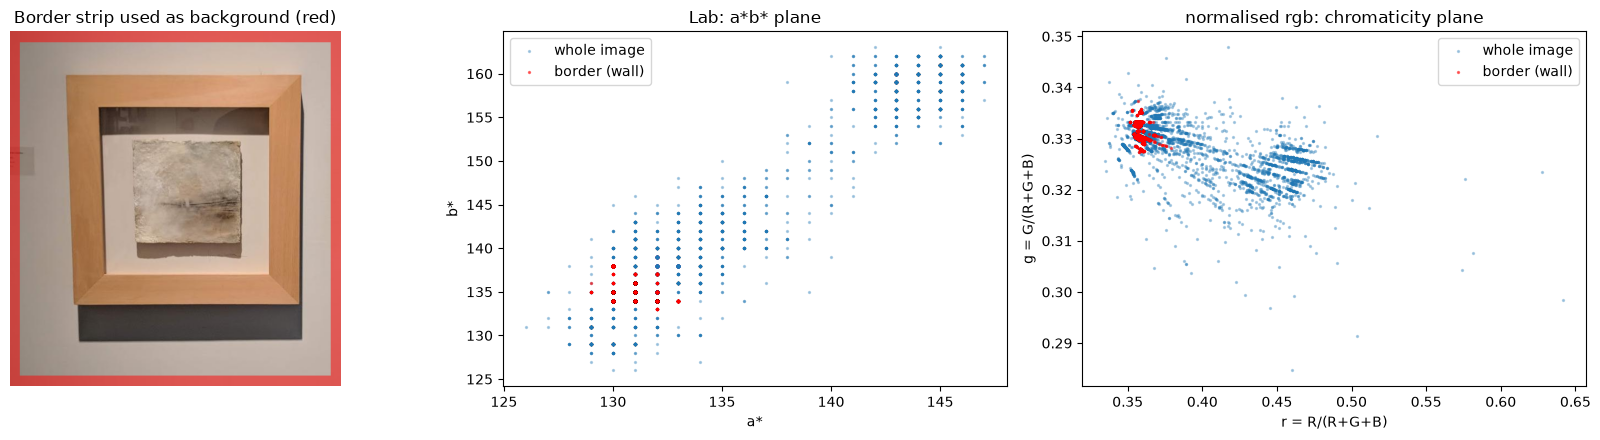

In [11]:
BORDER_RATIO = 0.03                       # outer 3% of each side is assumed to be wall
COLOR_MODELS = ["lab", "rgb"]             # "rgb" = normalised rgb (chromaticity)
SIGMA_FLOOR_VAR = {"lab": 1 / 12,         # quantisation error of 8-bit integer a*, b*
                   "rgb": 1e-8}           # chromaticity is computed in float: only avoids sigma = 0

def border_region(shape, border_ratio=BORDER_RATIO):
    #boolean map of the outer strip: border_ratio of the height (top/bottom) and of the width (left/right)
    h, w = shape[:2]
    bh, bw = max(1, round(border_ratio * h)), max(1, round(border_ratio * w))
    region = np.zeros((h, w), dtype=bool)
    region[:bh, :] = True
    region[-bh:, :] = True
    region[:, :bw] = True
    region[:, -bw:] = True
    return region   #boolean map -> corner pixels are only counted once

def color_features(image, space):
    #chroma: colour without light, (H, W, C)  /  luma: amount of light, (H, W)
    if space == "lab":
        lab = cv2.cvtColor(image, cv2.COLOR_BGR2LAB).astype(np.float32)
        return lab[..., 1:], lab[..., 0]                               # (a*, b*), L*
    if space == "rgb":
        bgr = image.astype(np.float32) + 1.0                           # +1 avoids 0/0 on black pixels
        chroma = bgr / bgr.sum(axis=-1, keepdims=True)                 # (b, g, r) / (b + g + r)
        luma = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY).astype(np.float32)
        return chroma, luma
    raise ValueError(f"Unknown colour space: {space}")

def background_model(image, space, border_ratio=BORDER_RATIO):
    #wall model learned from the border strip
    chroma, luma = color_features(image, space)
    border = border_region(luma.shape, border_ratio)
    bg_chroma = chroma[border]                                          # (N, C)
    return {"space": space, "chroma": chroma, "luma": luma,
            "mu": np.median(bg_chroma, axis=0),                         # wall colour
            "sigma": np.sqrt(bg_chroma.var(axis=0) + SIGMA_FLOOR_VAR[space]),
            "luma_wall": np.median(luma[border]) + 1e-6}                # wall lightness

#---------------------------------------------------------------------------------- 
#example: border strip + wall vs whole image in both chroma planes
ex = qsd2_imgs[0]
ex_rgb = cv2.cvtColor(ex, cv2.COLOR_BGR2RGB)
strip = border_region(ex.shape)
shown = ex_rgb.copy()
shown[strip] = (0.5 * shown[strip] + 0.5 * np.array([255, 0, 0])).astype(np.uint8)

model_lab_ex, model_rgb_ex = background_model(ex, "lab"), background_model(ex, "rgb")
print(f"{qsd2_files[0]}")
print(f"  Lab: wall (a*, b*) = {np.round(model_lab_ex['mu'], 2)}   L*_wall = {model_lab_ex['luma_wall']:.1f}")
print(f"  rgb: wall (b, g, r) = {np.round(model_rgb_ex['mu'], 4)}   grey_wall = {model_rgb_ex['luma_wall']:.1f}")

sub = np.random.default_rng(0).choice(strip.size, size=min(5000, strip.size), replace=False)
fig, axes = plt.subplots(1, 3, figsize=(17, 4.5))
axes[0].imshow(shown); axes[0].set_title("Border strip used as background (red)"); axes[0].axis("off")

ab_all, ab_wall = model_lab_ex["chroma"].reshape(-1, 2)[sub], model_lab_ex["chroma"][strip][::10]
axes[1].scatter(ab_all[:, 0], ab_all[:, 1], s=2, alpha=0.3, label="whole image")
axes[1].scatter(ab_wall[:, 0], ab_wall[:, 1], s=2, alpha=0.5, c="red", label="border (wall)")
axes[1].set_xlabel("a*"); axes[1].set_ylabel("b*"); axes[1].set_title("Lab: a*b* plane"); axes[1].legend()

ch_all, ch_wall = model_rgb_ex["chroma"].reshape(-1, 3)[sub], model_rgb_ex["chroma"][strip][::10]
axes[2].scatter(ch_all[:, 2], ch_all[:, 1], s=2, alpha=0.3, label="whole image")       #BGR order: 2 = r, 1 = g
axes[2].scatter(ch_wall[:, 2], ch_wall[:, 1], s=2, alpha=0.5, c="red", label="border (wall)")
axes[2].set_xlabel("r = R/(R+G+B)"); axes[2].set_ylabel("g = G/(R+G+B)")
axes[2].set_title("normalised rgb: chromaticity plane"); axes[2].legend()
plt.tight_layout(); plt.show()

### 3.2 Method A: per-channel thresholds

In [12]:
def method_a_mask(model, k=2.5):
    #wall if every chroma channel is inside [mu - k*sigma, mu + k*sigma]
    low  = model["mu"] - k * model["sigma"]
    high = model["mu"] + k * model["sigma"]
    is_wall = np.all((model["chroma"] >= low) & (model["chroma"] <= high), axis=-1)
    return ~is_wall   #True = painting

GRID_A = {"k": [1.5, 2.0, 2.5, 3.0, 4.0, 6.0]}     #same for both spaces (units of sigma)

### 3.3 Method B:  Euclidean distance

In [13]:
def chroma_distance(model):
    #Euclidean distance of every pixel to the wall colour in the chroma plane, (H, W)
    return np.sqrt(np.sum((model["chroma"] - model["mu"]) ** 2, axis=-1))

def method_b_mask(dist, tau):
    return dist > tau   #True = painting

GRID_B = {"lab": {"tau": [2, 3, 4, 6, 8, 12]},
          "rgb": {"tau": [0.01, 0.02, 0.03, 0.04, 0.06, 0.08]}}

### 3.4 Method C: Euclidean distance + dark-pixel rule

In [14]:
def luminance_ratio(model):
    #amount of light of every pixel relative to the wall, (H, W)
    return model["luma"] / model["luma_wall"]

def method_c_mask(dist, ratio, tau, tau2, rho):
    #rule 1: clearly different colour  OR  rule 2: much darker AND slightly different colour
    return (dist > tau) | ((ratio < rho) & (dist > tau2))   #True = painting

GRID_C = {"lab": {"tau": [3, 4, 6, 8],           "tau2": [1.0, 1.5, 2.5],        "rho": [0.6, 0.7, 0.8, 0.9]},
          "rgb": {"tau": [0.02, 0.03, 0.04, 0.06], "tau2": [0.008, 0.012, 0.02], "rho": [0.4, 0.5, 0.6, 0.7]}}

def raw_mask(model, method, params, dist=None, ratio=None):
    #common entry point for the three methods; dist / ratio can be passed precomputed (grid search)
    if method == "A":
        return method_a_mask(model, **params)
    dist = chroma_distance(model) if dist is None else dist
    if method == "B":
        return method_b_mask(dist, **params)
    ratio = luminance_ratio(model) if ratio is None else ratio
    return method_c_mask(dist, ratio, **params)

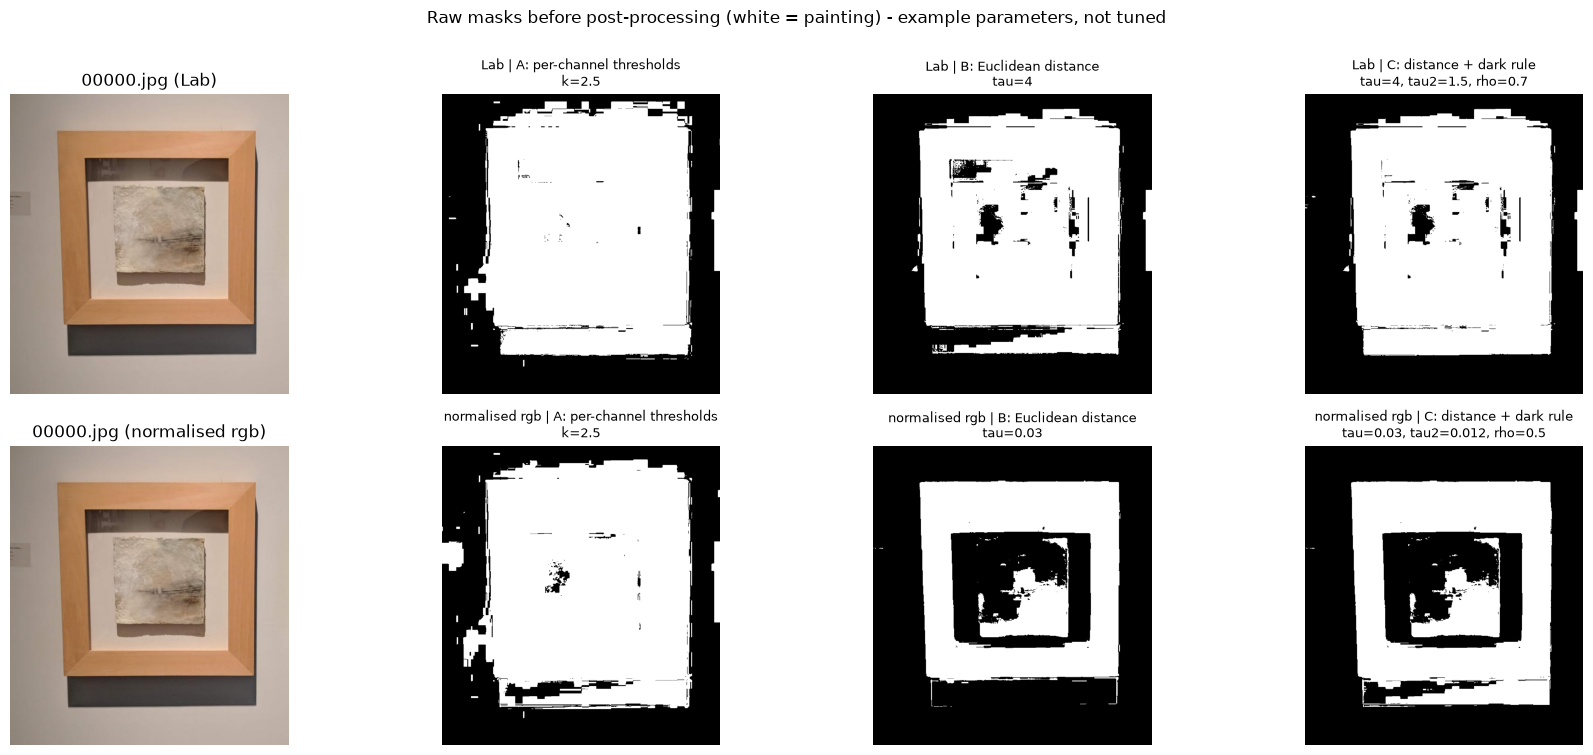

In [15]:
#example: raw masks of the 3 methods in the 2 colour spaces (example parameters, NOT tuned)
EXAMPLE_PARAMS = {
    "lab": {"A": {"k": 2.5}, "B": {"tau": 4},    "C": {"tau": 4,    "tau2": 1.5,   "rho": 0.7}},
    "rgb": {"A": {"k": 2.5}, "B": {"tau": 0.03}, "C": {"tau": 0.03, "tau2": 0.012, "rho": 0.5}},
}
METHOD_NAMES = {"A": "A: per-channel thresholds", "B": "B: Euclidean distance", "C": "C: distance + dark rule"}
SPACE_NAMES  = {"lab": "Lab", "rgb": "normalised rgb"}

fig, axes = plt.subplots(2, 4, figsize=(18, 7.5))
for row, (space, model) in enumerate([("lab", model_lab_ex), ("rgb", model_rgb_ex)]):
    axes[row, 0].imshow(ex_rgb); axes[row, 0].set_title(f"{qsd2_files[0]} ({SPACE_NAMES[space]})")
    for col, method in enumerate(["A", "B", "C"], start=1):
        params = EXAMPLE_PARAMS[space][method]
        axes[row, col].imshow(raw_mask(model, method, params), cmap="gray")
        axes[row, col].set_title(f"{SPACE_NAMES[space]} | {METHOD_NAMES[method]}\n"
                                 + ", ".join(f"{k}={v}" for k, v in params.items()), fontsize=9)
for ax in axes.ravel(): ax.axis("off")
plt.suptitle("Raw masks before post-processing (white = painting) - example parameters, not tuned", y=1.0)
plt.tight_layout(); plt.show()

### 3.4 Morphological post-processing: hole filling + largest connected component

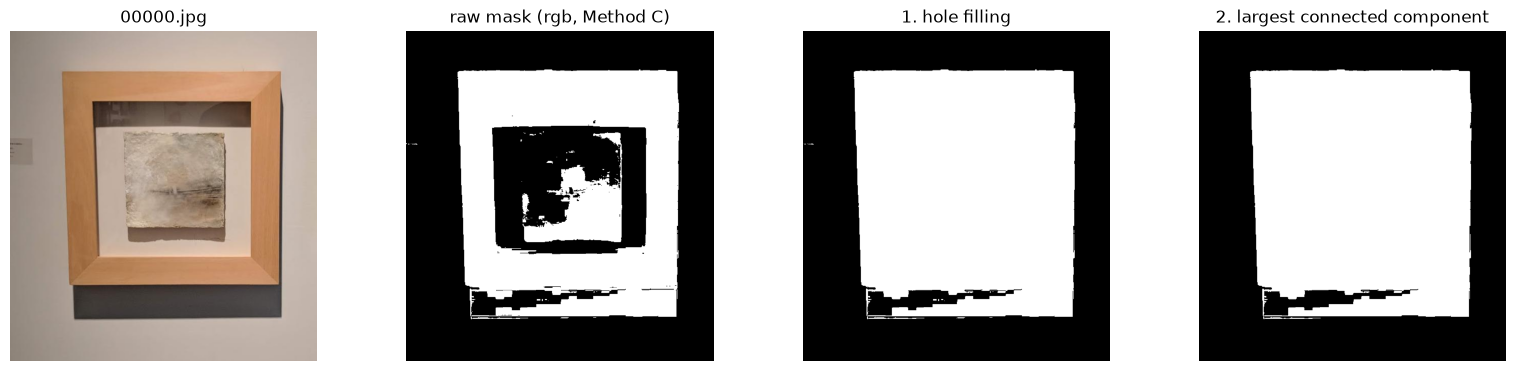

In [16]:
POST_MODES = ["none", "fill+lcc"]

def fill_holes(mask):
    #G&W 9.5.9: flood the background from the border; whatever background is not reached is a hole
    padded = np.pad(mask.astype(np.uint8), 1, constant_values=0)   #padding guarantees (0,0) is background
    ff_mask = np.zeros((padded.shape[0] + 2, padded.shape[1] + 2), np.uint8)
    cv2.floodFill(padded, ff_mask, (0, 0), 1)
    holes = padded[1:-1, 1:-1] == 0
    return mask.astype(bool) | holes

def largest_component(mask):
    n, labels, stats, _ = cv2.connectedComponentsWithStats(mask.astype(np.uint8), connectivity=8)
    if n <= 1:                     #only background
        return mask.astype(bool)
    biggest = 1 + np.argmax(stats[1:, cv2.CC_STAT_AREA])
    return labels == biggest

def postprocess_mask(mask, mode="fill+lcc"):
    if mode == "none":
        return mask.astype(bool)
    m = largest_component(fill_holes(mask))
    if not m.any():                #nothing detected: fall back to the whole image
        m = np.ones_like(m, dtype=bool)
    return m

def segment_painting(image, space="rgb", method="C", params=None, post="fill+lcc"):
    #full Task 3 pipeline for one image -> uint8 mask (0/255), same size as the image
    params = EXAMPLE_PARAMS[space][method] if params is None else params
    model = background_model(image, space)
    return postprocess_mask(raw_mask(model, method, params), post).astype(np.uint8) * 255

#---------------------------------------------------------------------------------- 
#example: effect of each step (normalised rgb, Method C, example parameters)
raw_ex = raw_mask(model_rgb_ex, "C", EXAMPLE_PARAMS["rgb"]["C"])
filled_ex = fill_holes(raw_ex)
steps = {"raw mask (rgb, Method C)": raw_ex, "1. hole filling": filled_ex,
         "2. largest connected component": largest_component(filled_ex)}

fig, axes = plt.subplots(1, len(steps) + 1, figsize=(16, 3.8))
axes[0].imshow(ex_rgb); axes[0].set_title(qsd2_files[0])
for ax, (name, m) in zip(axes[1:], steps.items()):
    ax.imshow(m, cmap="gray"); ax.set_title(name)
for ax in axes: ax.axis("off")
plt.tight_layout(); plt.show()

## Task 4: Background removal evaluation

In [17]:
EPS = 1e-10

#ground-truth masks (same name as the query, .png)
qsd2_gt_masks = []
for f in qsd2_files:
    gt_path = os.path.join(qsd2_path, os.path.splitext(f)[0] + ".png")
    gt = cv2.imread(gt_path, cv2.IMREAD_GRAYSCALE)
    if gt is None:
        raise IOError(f"Could not read GT mask {gt_path}")
    qsd2_gt_masks.append(gt > 0)

def mask_counts(pred, gt):
    pred, gt = pred > 0, gt > 0
    assert pred.shape == gt.shape, f"Shape mismatch {pred.shape} vs {gt.shape}"
    tp = np.count_nonzero(pred & gt)
    fp = np.count_nonzero(pred & ~gt)
    fn = np.count_nonzero(~pred & gt)
    return tp, fp, fn

def prf(tp, fp, fn):
    p = tp / (tp + fp + EPS)
    r = tp / (tp + fn + EPS)
    return p, r, 2 * p * r / (p + r + EPS)

def summarize_counts(counts):
    #counts: list of (TP, FP, FN), one per image
    counts = np.asarray(counts, dtype=np.float64)
    per_image = np.array([prf(*c) for c in counts])                       #(N, 3)
    mean_p, mean_r, mean_f1 = per_image.mean(axis=0)
    glob_p, glob_r, glob_f1 = prf(*counts.sum(axis=0))
    summary = {"Precision": mean_p, "Recall": mean_r, "F1": mean_f1,
               "Global P": glob_p, "Global R": glob_r, "Global F1": glob_f1}
    return summary, per_image

def evaluate_masks(pred_masks, gt_masks):
    return summarize_counts([mask_counts(p, g) for p, g in zip(pred_masks, gt_masks)])

### 4.1 Grid search and comparison of methods

In [18]:
def params_label(params):
    return ", ".join(f"{k}={v}" for k, v in params)

# configurations without post-processing: (space, method, params)   params = tuple of (name, value)
base_configs = []
for space in COLOR_MODELS:
    base_configs += [(space, "A", (("k", k),)) for k in GRID_A["k"]]
    base_configs += [(space, "B", (("tau", t),)) for t in GRID_B[space]["tau"]]
    grid_c = GRID_C[space]
    base_configs += [(space, "C", (("tau", t), ("tau2", t2), ("rho", r)))
                     for t in grid_c["tau"] for t2 in grid_c["tau2"] if t2 < t for r in grid_c["rho"]]
configs = [(space, method, params, post) for space, method, params in base_configs for post in POST_MODES]
print(f"{len(base_configs)} colour configurations x {len(POST_MODES)} post-processing modes = {len(configs)}")

# loop over images: the wall model and the maps are computed once per image and colour space
# every raw mask is computed once and post-processed in every mode; only (TP, FP, FN) are kept
counts = {cfg: [] for cfg in configs}
for img, gt in tqdm(zip(qsd2_imgs, qsd2_gt_masks), total=len(qsd2_imgs), desc="Grid search"):
    cache = {}
    for space in COLOR_MODELS:
        model = background_model(img, space)
        cache[space] = (model, chroma_distance(model), luminance_ratio(model))
    for space, method, params in base_configs:
        model, dist, ratio = cache[space]
        raw = raw_mask(model, method, dict(params), dist, ratio)
        for post in POST_MODES:
            counts[(space, method, params, post)].append(mask_counts(postprocess_mask(raw, post), gt))
    del cache

# results table
rows = []
for cfg_id, ((space, method, params, post), cfg_counts) in enumerate(counts.items()):
    summary, _ = summarize_counts(cfg_counts)
    rows.append({"cfg_id": cfg_id, "Space": SPACE_NAMES[space], "Method": method,
                 "Params": params_label(params), "Post": post, **summary, **dict(params)})

num_cols = ["Precision", "Recall", "F1", "Global P", "Global R", "Global F1"]
df_grid_order = pd.DataFrame(rows)                    #keeps the grid order
df_grid_order[num_cols] = df_grid_order[num_cols].round(4)
df_bg = df_grid_order.sort_values("F1", ascending=False).reset_index(drop=True)
show_cols = ["Space", "Method", "Params", "Post"] + num_cols

# tables for the slides
print("Methods:", " | ".join(METHOD_NAMES.values()))
print("\n=== TOP 10 CONFIGURATIONS (QSD2-W2, ranked by mean F1) ===")
display(df_bg[show_cols].head(10))

best_per_group = (df_bg.loc[df_bg.groupby(["Space", "Method", "Post"])["F1"].idxmax()]
                  .sort_values(["Post", "F1"], ascending=[True, False]).reset_index(drop=True))
print("\n=== BEST CONFIGURATION PER COLOUR SPACE / METHOD / POST-PROCESSING ===")
display(best_per_group[show_cols])

print("\n=== MAIN COMPARISON: best mean F1 per method and colour space (post = fill+lcc) ===")
display(df_bg[df_bg.Post == "fill+lcc"].pivot_table(index="Method", columns="Space", values="F1", aggfunc="max"))

print("\n=== EFFECT OF THE POST-PROCESSING: best mean F1 ===")
display(df_bg.pivot_table(index=["Space", "Method"], columns="Post", values="F1", aggfunc="max")[POST_MODES])

for space in COLOR_MODELS:
    df_c = df_bg[(df_bg.Method == "C") & (df_bg.Space == SPACE_NAMES[space]) & (df_bg.Post == "fill+lcc")]
    print(f"\n=== METHOD C ({SPACE_NAMES[space]}): best mean F1 (over tau2) for each tau / rho ===")
    display(df_c.pivot_table(index="tau", columns="rho", values="F1", aggfunc="max"))

# save
output_dir = os.path.join("results", "week2_results")
os.makedirs(output_dir, exist_ok=True)
df_bg.to_csv(os.path.join(output_dir, "bg_removal_grid_search.csv"), index=False)
best_per_group.to_csv(os.path.join(output_dir, "bg_removal_best_per_method.csv"), index=False)

best_cfg = df_bg.iloc[0]
best_cfg_tuple = configs[int(best_cfg.cfg_id)]
print(f"\nBest: {best_cfg.Space} | Method {best_cfg.Method} | {best_cfg.Params} | post={best_cfg.Post} "
      f"-> P={best_cfg.Precision:.4f}  R={best_cfg.Recall:.4f}  F1={best_cfg.F1:.4f}")

116 colour configurations x 2 post-processing modes = 232


Grid search:   0%|          | 0/30 [00:00<?, ?it/s]

Methods: A: per-channel thresholds | B: Euclidean distance | C: distance + dark rule

=== TOP 10 CONFIGURATIONS (QSD2-W2, ranked by mean F1) ===


,Space,Method,Params,Post,Precision,Recall,F1,Global P,Global R,Global F1
0,Lab,C,"tau=8, tau2=1.5, rho=0.6",fill+lcc,0.9562,0.9888,0.9715,0.9700,0.9920,0.9809
1,Lab,C,"tau=8, tau2=1.0, rho=0.6",fill+lcc,0.9548,0.9893,0.9710,0.9696,0.9922,0.9808
2,Lab,C,"tau=8, tau2=1.5, rho=0.7",fill+lcc,0.9476,0.9928,0.9690,0.9656,0.9931,0.9792
3,normalised rgb,C,"tau=0.03, tau2=0.012, rho=0.4",fill+lcc,0.9506,0.9882,0.9683,0.9700,0.9920,0.9808
4,Lab,C,"tau=8, tau2=1.0, rho=0.7",fill+lcc,0.9456,0.9933,0.9682,0.9650,0.9933,0.9790
5,normalised rgb,C,"tau=0.03, tau2=0.008, rho=0.4",fill+lcc,0.9476,0.9883,0.9669,0.9694,0.9920,0.9806
6,normalised rgb,C,"tau=0.04, tau2=0.012, rho=0.6",fill+lcc,0.9552,0.9800,0.9662,0.9803,0.9626,0.9714
7,normalised rgb,C,"tau=0.03, tau2=0.012, rho=0.5",fill+lcc,0.9453,0.9889,0.9660,0.9691,0.9922,0.9805
8,normalised rgb,C,"tau=0.04, tau2=0.012, rho=0.4",fill+lcc,0.9639,0.9704,0.9658,0.9827,0.9600,0.9712
9,normalised rgb,C,"tau=0.04, tau2=0.008, rho=0.6",fill+lcc,0.9535,0.9804,0.9655,0.9797,0.9627,0.9712



=== BEST CONFIGURATION PER COLOUR SPACE / METHOD / POST-PROCESSING ===


...


=== METHOD C (Lab): best mean F1 (over tau2) for each tau / rho ===


rho,0.6,0.7,0.8,0.9
tau,,,,
3.0,0.9084,0.9080,0.9056,0.9026
4.0,0.9430,0.9384,0.9280,0.9317
6.0,0.9642,0.9611,0.9486,0.9330
8.0,0.9715,0.9690,0.9570,0.9387



=== METHOD C (normalised rgb): best mean F1 (over tau2) for each tau / rho ===


rho,0.4,0.5,0.6,0.7
tau,,,,
0.02,0.9448,0.9435,0.9434,0.9407
0.03,0.9683,0.9660,0.9655,0.9622
0.04,0.9658,0.9635,0.9662,0.9618
0.06,0.9214,0.9204,0.9290,0.9240



Best: Lab | Method C | tau=8, tau2=1.5, rho=0.6 | post=fill+lcc -> P=0.9562  R=0.9888  F1=0.9715


### 4.2 Qualitative results: worst and best cases

=== PER-IMAGE RESULTS OF THE BEST CONFIGURATION (worst first) ===


,Query,Precision,Recall,F1
0,00013.jpg,0.7910,0.9832,0.8767
1,00014.jpg,0.8286,0.9631,0.8908
2,00000.jpg,0.8582,1.0000,0.9237
3,00004.jpg,0.8914,0.9902,0.9382
4,00015.jpg,0.9067,0.9895,0.9463
5,00029.jpg,0.9258,1.0000,0.9615
6,00005.jpg,0.9328,0.9961,0.9634
7,00025.jpg,0.9571,0.9698,0.9634
8,00026.jpg,0.9340,0.9995,0.9656
9,00002.jpg,0.9821,0.9517,0.9667


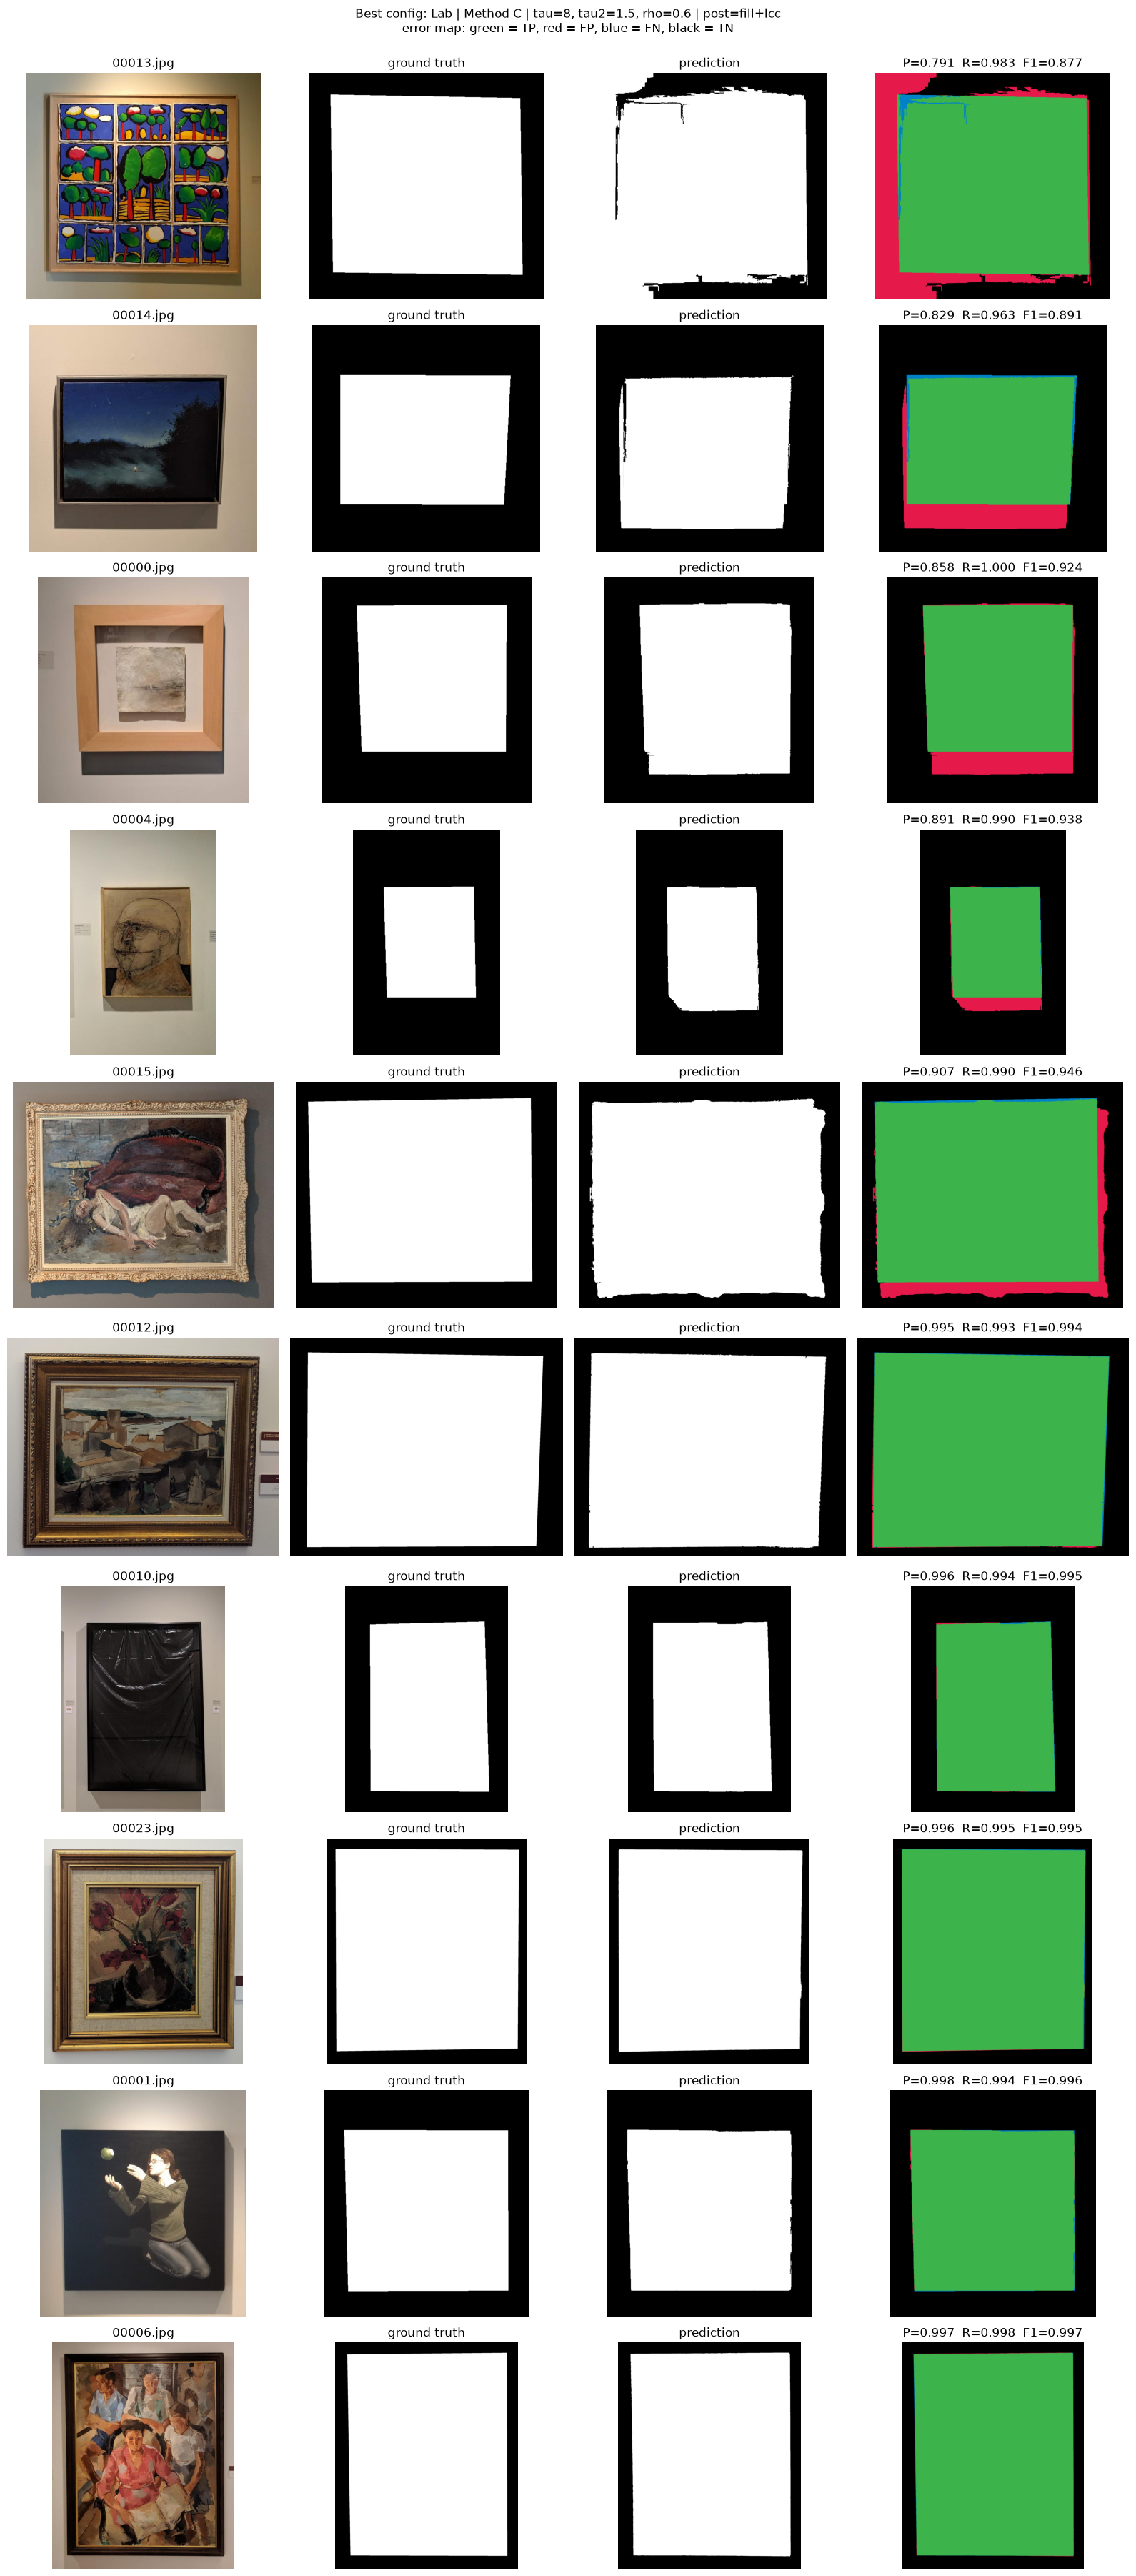

In [19]:
def predict_config(space, method, params, post):
    #masks of every query for one configuration
    return [segment_painting(img, space, method, dict(params), post) for img in qsd2_imgs]

def error_map(pred, gt):
    pred, gt = pred > 0, gt > 0
    out = np.zeros(pred.shape + (3,), np.uint8)          #TN: black
    out[pred & gt]  = (60, 180, 75)                      #TP: green
    out[pred & ~gt] = (230, 25, 75)                      #FP: red
    out[~pred & gt] = (0, 130, 200)                      #FN: blue
    return out

best_preds = predict_config(*best_cfg_tuple)
_, per_image = evaluate_masks(best_preds, qsd2_gt_masks)

df_per_image = pd.DataFrame(per_image, columns=["Precision", "Recall", "F1"]).round(4)
df_per_image.insert(0, "Query", qsd2_files)
df_per_image = df_per_image.sort_values("F1").reset_index(drop=True)
print("=== PER-IMAGE RESULTS OF THE BEST CONFIGURATION (worst first) ===")
display(df_per_image)

shown_idx = list(df_per_image.index[:5]) + list(df_per_image.index[-5:])   #5 worst + 5 best
fig, axes = plt.subplots(len(shown_idx), 4, figsize=(16, 3.6 * len(shown_idx)))
for row, idx in zip(axes, shown_idx):
    q = qsd2_files.index(df_per_image.loc[idx, "Query"])
    img, pred, gt = qsd2_imgs[q], best_preds[q], qsd2_gt_masks[q]
    r = df_per_image.loc[idx]
    row[0].imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB)); row[0].set_title(qsd2_files[q])
    row[1].imshow(gt, cmap="gray");   row[1].set_title("ground truth")
    row[2].imshow(pred, cmap="gray"); row[2].set_title("prediction")
    row[3].imshow(error_map(pred, gt))
    row[3].set_title(f"P={r.Precision:.3f}  R={r.Recall:.3f}  F1={r.F1:.3f}")
    for ax in row: ax.axis("off")
plt.suptitle(f"Best config: {best_cfg.Space} | Method {best_cfg.Method} | {best_cfg.Params} | post={best_cfg.Post}\n"
             "error map: green = TP, red = FP, blue = FN, black = TN", y=1.0)
plt.tight_layout()
plt.savefig(os.path.join(output_dir, "bg_removal_worst_best.png"), dpi=120, bbox_inches="tight")
plt.show()